# 확률 분포와 손실 함수의 연결

[확률 구현](../src/probability.py)의 정규 PDF, 베르누이 PMF, 안정적인 Softmax를 확인하고 최대우도추정(MLE)에서 손실 함수를 유도했다. $N(\mu,\sigma^2)$ 규약을 사용하여 **N(2,.5)의 분산은 .5, 표준편차는 √.5**로 해석했다.

In [1]:
from pathlib import Path
import os
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ['MPLCONFIGDIR'] = str(ROOT / '.cache' / 'matplotlib')
import numpy as np
np.random.seed(42)
print('Python:', sys.executable)
print('NumPy:', np.__version__)
import matplotlib.pyplot as plt
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#14213d","#a67c20","#64748b","#1d4ed8"])
from src.probability import ProbabilityLoss, plot_normal_distributions, plot_bernoulli_distributions


Python: /Users/oliverjoo/Dev/Anaconda/anaconda3/envs/py312/bin/python
NumPy: 1.26.4


## 1. 정규분포 PDF

$$p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]$$

연속 변수는 한 점의 확률이 아니라 구간의 면적이 확률이다. 키 측정 오차가 평균 0 주변에 모인다는 상황을 생각할 수 있다. N(2,.5)는 중심이 2로 이동하고 분산이 작아서 더 좁고 높다.

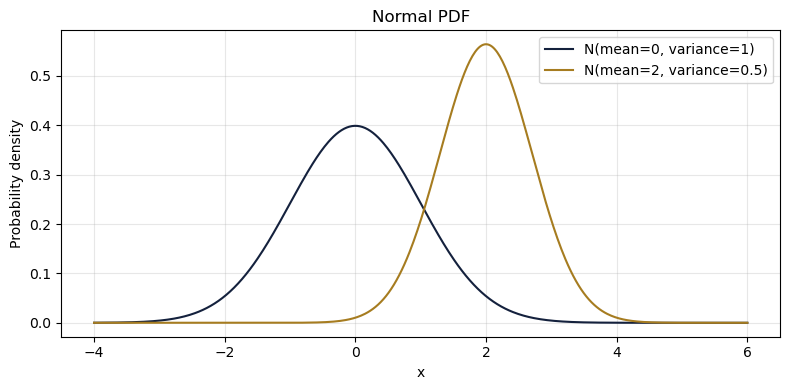

N(0,1): integral≈1.0000000000, std=1.000000
N(2,0.5): integral≈1.0000000000, std=0.707107


In [2]:
figure = plot_normal_distributions()
figure.savefig(ROOT/'outputs'/'normal_pdf.png', dpi=150, bbox_inches='tight')
plt.show()
x = np.linspace(-10, 10, 20001)
for mean, variance in [(0,1),(2,.5)]:
    integral = np.trapz(ProbabilityLoss.normal_pdf(x, mean, variance), x)
    print(f'N({mean},{variance}): integral≈{integral:.10f}, std={np.sqrt(variance):.6f}')

## 2. 베르누이 PMF

$$P(Y=y)=p^y(1-p)^{1-y},\quad y\in\{0,1\}$$

한 번의 성공/실패를 나타낸다. 정답을 맞힐 확률 p=.3이면 틀릴 확률은 .7이다. B(.3), B(.7)의 각 막대 높이는 확률이며 두 높이의 합은 1이다.

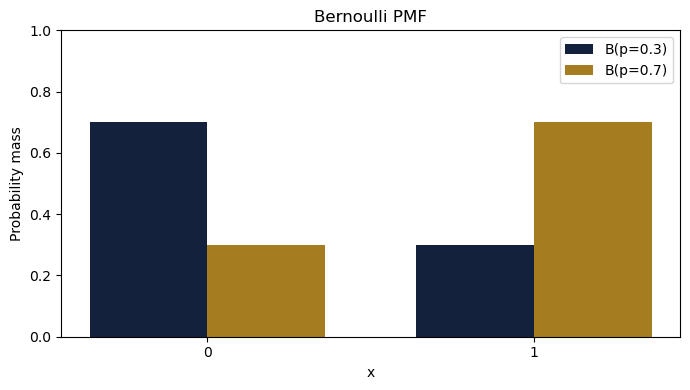

B(0.3): [0.7 0.3], sum=1.0
B(0.7): [0.3 0.7], sum=1.0


In [3]:
figure = plot_bernoulli_distributions()
figure.savefig(ROOT/'outputs'/'bernoulli_pmf.png', dpi=150, bbox_inches='tight')
plt.show()
for p in [.3,.7]:
    pmf = ProbabilityLoss.bernoulli_pmf(np.array([0,1]), p)
    print(f'B({p}): {pmf}, sum={pmf.sum()}')

## 3. Softmax를 직접 구현

$$q_j=\frac{e^{z_j-m}}{\sum_k e^{z_k-m}},\quad m=\max_k z_k$$

모든 항에서 같은 m을 빼도 비율은 바뀌지 않는다. 가장 큰 지수의 입력이 0이 되어 `exp(1000)` 같은 overflow를 피한다. 세 종류 중 하나를 고르는 분류 모델의 점수를 확률로 바꾸는 경우에 사용한다.

In [4]:
probabilities = ProbabilityLoss.softmax(np.array([1000.,1001.,1002.]))
print('Softmax:', probabilities)
print('sum:', probabilities.sum(), 'error:', abs(probabilities.sum()-1))
assert abs(probabilities.sum()-1) <= 1e-6
np.testing.assert_allclose(probabilities, ProbabilityLoss.softmax([0,1,2]))
from scripts.assessment import verify_softmax_cases
cases = verify_softmax_cases()
for row in cases:
    print('logits=', row['logits'], 'sum=', row['sum'],
          'abs_error=', row['absolute_sum_error'], 'tolerance=', row['tolerance'],
          'status=', 'PASS' if row['passed'] else 'FAIL')
assert all(row['passed'] for row in cases)


Softmax: [0.09003057 0.24472847 0.66524096]
sum: 0.9999999999999999 error: 1.1102230246251565e-16
logits= [1000.0, 1001.0, 1002.0] sum= 0.9999999999999999 abs_error= 1.1102230246251565e-16 tolerance= 1e-06 status= PASS
logits= [-1000.0, -1001.0, -1002.0] sum= 0.9999999999999999 abs_error= 1.1102230246251565e-16 tolerance= 1e-06 status= PASS
logits= [0.0, 0.0, 0.0] sum= 1.0 abs_error= 0.0 tolerance= 1e-06 status= PASS
logits= [2.0, 1.0, -3.0] sum= 1.0000000000000002 abs_error= 2.220446049250313e-16 tolerance= 1e-06 status= PASS
logits= [1000.0] sum= 1.0 abs_error= 0.0 tolerance= 1e-06 status= PASS


## 4. MSE 최소화와 정규분포의 MLE

관측값이 서로 독립이며 $y_i=f_\theta(x_i)+\epsilon_i$, $\epsilon_i\sim N(0,\sigma^2)$라고 가정한다. **분산 σ²는 양수인 고정값**이다.

$$p(y_i|x_i,\theta)=\frac1{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_i-f_\theta(x_i))^2}{2\sigma^2}\right]$$
$$\mathcal L(\theta)=\prod_{i=1}^n p(y_i|x_i,\theta)$$

곱은 작아지기 쉬워 자연로그로 바꾼다. 로그는 증가 함수이므로 최대가 되는 θ는 동일하다.

$$-\ln\mathcal L(\theta)=\frac n2\ln(2\pi\sigma^2)+\frac1{2\sigma^2}\sum_{i=1}^n(y_i-f_\theta(x_i))^2$$
$$\operatorname*{argmax}_\theta\mathcal L=\operatorname*{argmin}_\theta[-\ln\mathcal L]=\operatorname*{argmin}_\theta\frac1n\sum_{i=1}^n(y_i-f_\theta(x_i))^2$$

첫 항은 θ와 무관한 상수, 두 번째 항의 계수는 양수다. 따라서 같은 θ를 선택한다. **값이 같은 것은 아니며, 최소화하는 θ가 같다.** 예를 들어 측정 잡음이 정규분포인 온도 예측에서 제곱 오차를 사용하는 근거다. 분산까지 학습하면 식의 다른 항도 변하므로 고정 분산 가정을 생략하면 안 된다.

### 정식 전개의 각 단계

1. 조건부 정규분포를 모델 가정으로 선택한다. 이는 실제 잡음이 정규인지에 대한 가정이다.
2. 독립 표본의 확률을 곱해 전체 우도를 만든다.
3. 로그는 증가 함수라 최대점이 유지되고 곱의 로그가 합이 된다.

$$\ln\mathcal L=\sum_{i=1}^n\left[-\frac12\ln(2\pi\sigma^2)-\frac{(y_i-f_\theta(x_i))^2}{2\sigma^2}\right]$$

4. 부호를 바꿔 NLL을 최소화한다.
5. θ에 무관한 상수와 양의 고정 배율을 제거한다. 표본 수 n도 고정이다.

$$\mathrm{NLL}=C+\frac{n}{2\sigma^2}\mathrm{MSE}$$

실제 예시: 온도 센서의 같은 분산 정규 잡음. 분산이 표본마다 다르면 동일 가중치의 MSE 대신 분산의 역수로 가중한 제곱오차가 나온다.


In [5]:
y = np.array([1.,2.,3.])
predictions = np.array([[1.,2.,3.],[.8,2.2,2.7],[0.,0.,0.]])
variance = .5
mse = np.mean((predictions-y)**2, axis=1)
negative_log_likelihood = len(y)/2*np.log(2*np.pi*variance) + len(y)*mse/(2*variance)
print('MSE:',mse)
print('Gaussian NLL:',negative_log_likelihood)
assert np.argmin(mse) == np.argmin(negative_log_likelihood)

MSE: [0.         0.05666667 4.66666667]
Gaussian NLL: [ 1.71709483  1.88709483 15.71709483]


## 5. Bernoulli MLE와 Binary Cross-Entropy

독립된 이진 정답 $y_i\in\{0,1\}$와 성공 확률 $q_i=f_\theta(x_i)$를 사용한다.

$$\mathcal L(\theta)=\prod_i q_i^{y_i}(1-q_i)^{1-y_i}$$
$$-\ln\mathcal L(\theta)=-\sum_i[y_i\ln q_i+(1-y_i)\ln(1-q_i)]$$

우변이 BCE의 합이다. 표본 수 n으로 나눈 평균 BCE도 같은 최소점을 가진다. 정답이 1인데 q가 작으면 $-\ln q$가 크게 벌점을 준다.

## 6. Categorical MLE와 Cross-Entropy

C개 중 하나가 정답인 one-hot 벡터 $y_{ic}$와 Softmax 확률 $q_{ic}$를 사용한다.

$$p(y_i|x_i,\theta)=\prod_{c=1}^Cq_{ic}^{y_{ic}}$$
$$-\ln\mathcal L(\theta)=-\sum_i\sum_c y_{ic}\ln q_{ic}$$

이 식이 categorical cross-entropy다. one-hot 정답에서는 정답 클래스의 $-\ln q$만 남는다. 베르누이는 두 상태, 카테고리 분포는 여러 클래스의 단일 선택에 대응한다.

### 확률 곱 → 로그 합 → BCE/CE: 기호 연결

베르누이의 로그우도에서 지수는 곱의 계수로 내려온다.

$$\ln\mathcal L=\sum_i\ln\left[q_i^{y_i}(1-q_i)^{1-y_i}\right]
=\sum_i\left[y_i\ln q_i+(1-y_i)\ln(1-q_i)\right]$$

부호를 바꾸면 BCE 합이다. 한 번의 클릭 여부처럼 이진 정답에 대응한다.
카테고리 분포에서는 표본별 우도가 정답 클래스의 확률이며, one-hot 지수가 이 선택을 표현한다.

$$\mathcal L=\prod_i\prod_c q_{ic}^{y_{ic}},\quad
\ln\mathcal L=\sum_i\sum_c y_{ic}\ln q_{ic}$$

음의 부호를 붙이면 CE 합이다. 세 과일 중 하나를 분류하는 예에서 정답이 세 번째라면 한 표본의 NLL은 $-\ln q_{i3}$이다.
이 유도는 sum loss 기준이며 n으로 나눈 평균 loss도 같은 최소화 파라미터를 고른다.


In [6]:
bce = -np.log(.6472915699946178)  # 고정 역전파 예제의 y_true=1
one_hot = np.array([0.,0.,1.])
ce = -np.sum(one_hot*np.log(probabilities))
print('Bernoulli BCE:',bce)
print('Categorical CE:',ce, 'correct-class NLL:',-np.log(probabilities[2]))
assert np.isclose(ce,-np.log(probabilities[2]))

Bernoulli BCE: 0.4349584368514606
Categorical CE: 0.40760596444438046 correct-class NLL: 0.40760596444438046


## 7. 전개한 수식과 실제 분포 확률의 독립 검산

아래 셀은 직접 계산한 정규 PDF, 베르누이 PMF, 카테고리 확률로 우도를 만든 뒤 -log를 취한다.
그 결과를 앞에서 유도한 MSE 기반 NLL·BCE·CE와 비교하여 각 오차와 PASS를 저장한다.
정규 후보 세 개의 최소점 일치는 후보 집합의 수치 예시이며, 일반적인 동치의 근거는 위 기호 유도다.
구현: [verify_loss_likelihood](../scripts/assessment.py). 결과: [검산 JSON](../reports/loss_likelihood_checks.json).

In [7]:
import json
from scripts.assessment import verify_loss_likelihood
checks = verify_loss_likelihood()
print(json.dumps(checks, ensure_ascii=False, indent=2))
assert checks['passed']
(ROOT/'reports'/'loss_likelihood_checks.json').write_text(json.dumps(checks, indent=2)+'\n', encoding='utf-8')
print('MSE / BCE / CE likelihood verification: PASS; tolerance=1e-12')

{
  "gaussian": {
    "targets": [
      1.0,
      2.0,
      3.0
    ],
    "predictions": [
      [
        1.0,
        2.0,
        3.0
      ],
      [
        0.8,
        2.2,
        2.7
      ],
      [
        0.0,
        0.0,
        0.0
      ]
    ],
    "variance": 0.5,
    "mse": [
      0.0,
      0.05666666666666664,
      4.666666666666667
    ],
    "nll_from_pdf": [
      1.7170948287741004,
      1.8870948287740998,
      15.717094828774101
    ],
    "nll_from_mse": [
      1.7170948287741004,
      1.8870948287741003,
      15.717094828774101
    ],
    "maximum_absolute_error": 4.440892098500626e-16,
    "same_minimizer_among_candidates": true
  },
  "bernoulli": {
    "labels": [
      1.0,
      0.0,
      1.0
    ],
    "probabilities": [
      0.8,
      0.3,
      0.6
    ],
    "likelihood": 0.33599999999999997,
    "nll": 1.0906441190189329,
    "bce_sum": 1.0906441190189329,
    "absolute_error": 0.0
  },
  "categorical": {
    "one_hot": [
      [
   